In [1]:
import os

from pathlib import Path

from matplotlib import pyplot as plt
plt.style.use(Path(os.environ["HOME"]) / "default.mplstyle")

import slugpy
from LWphotorates.stellar_spectra.utils import convert_slug_spec_to_xr

# have a brief look at the SLUG output files

In [2]:
model_name = "salp_zem3_1_300"
spec_data = slugpy.read_cluster_spec(
    model_name,
    Path(os.environ["SLUG_DATA_DIR"]) / model_name,
    fmt="bin")
cluster_data = slugpy.read_cluster_prop(
    model_name,
    Path(os.environ["SLUG_DATA_DIR"]) / model_name,
    fmt="bin")

Text(0, 0.5, 'live mass  [M$_\\odot$]')

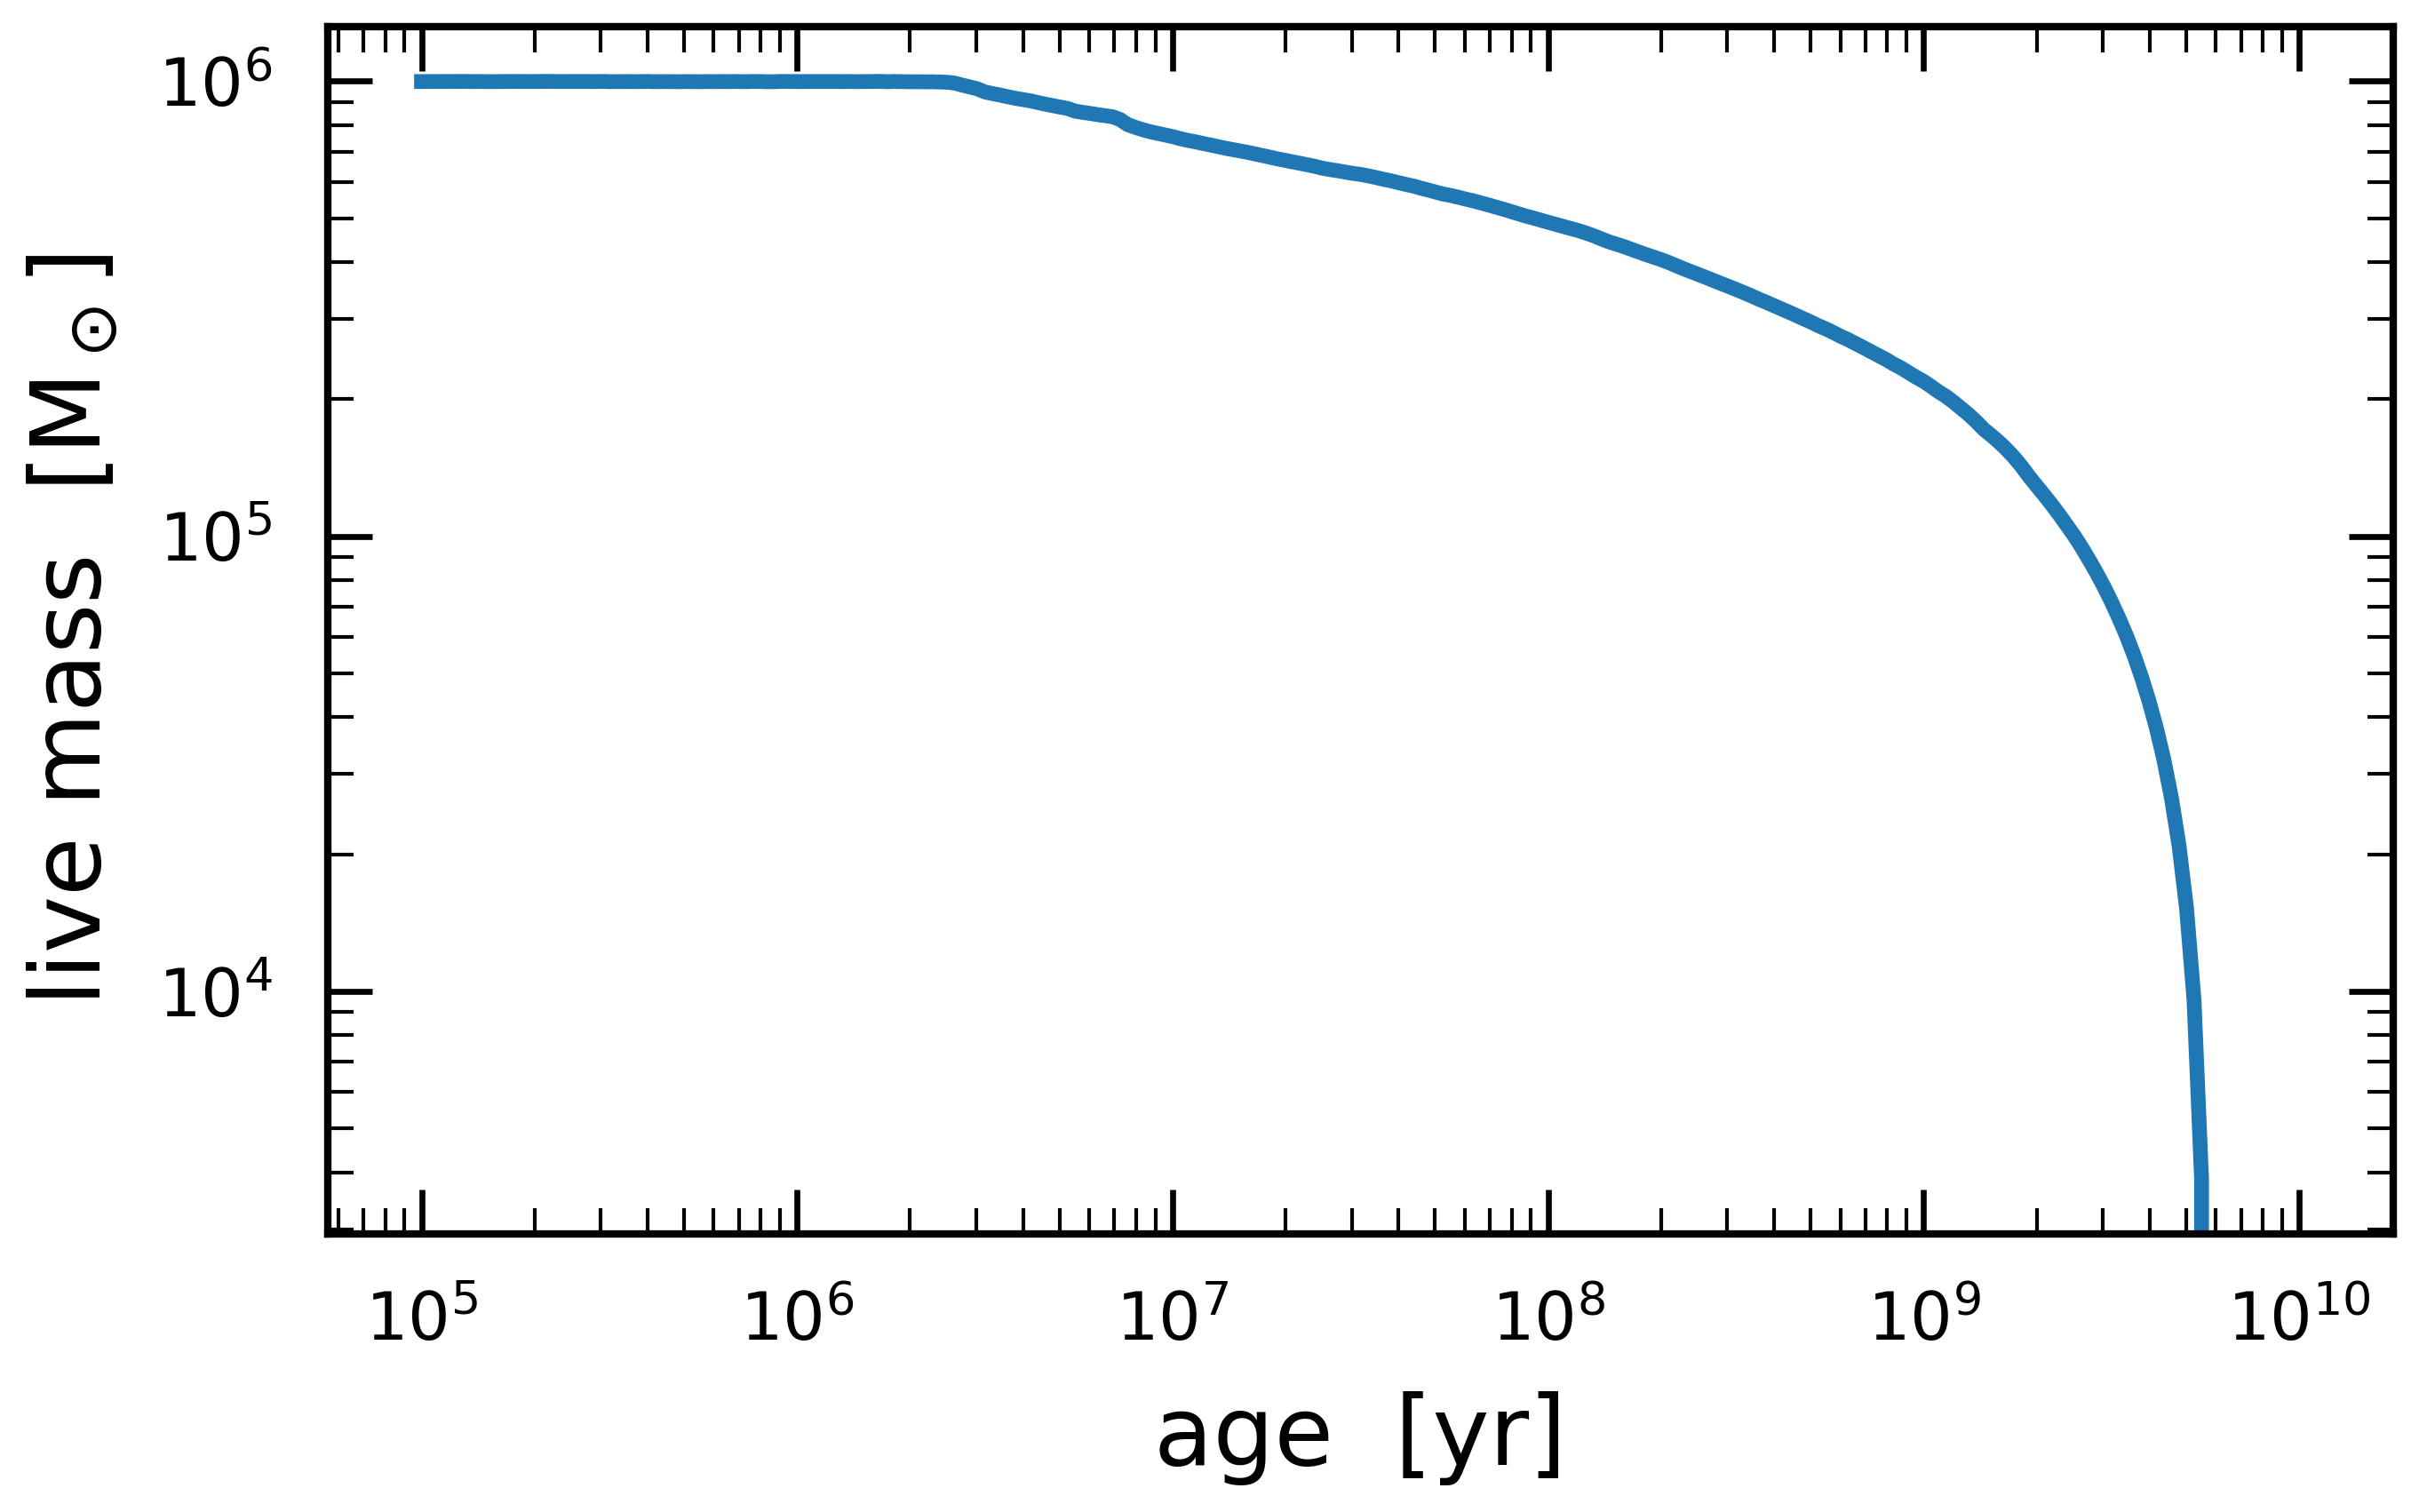

In [5]:
fig, ax = plt.subplots()
ax.plot(cluster_data.time, cluster_data.live_mass, lw=4)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("age  [yr]")
ax.set_ylabel(r"live mass  [M$_\odot$]")

Text(0, 0.5, 'L$_\\lambda$  [erg s$^{-1}$ $\\AA^{-1}$]')

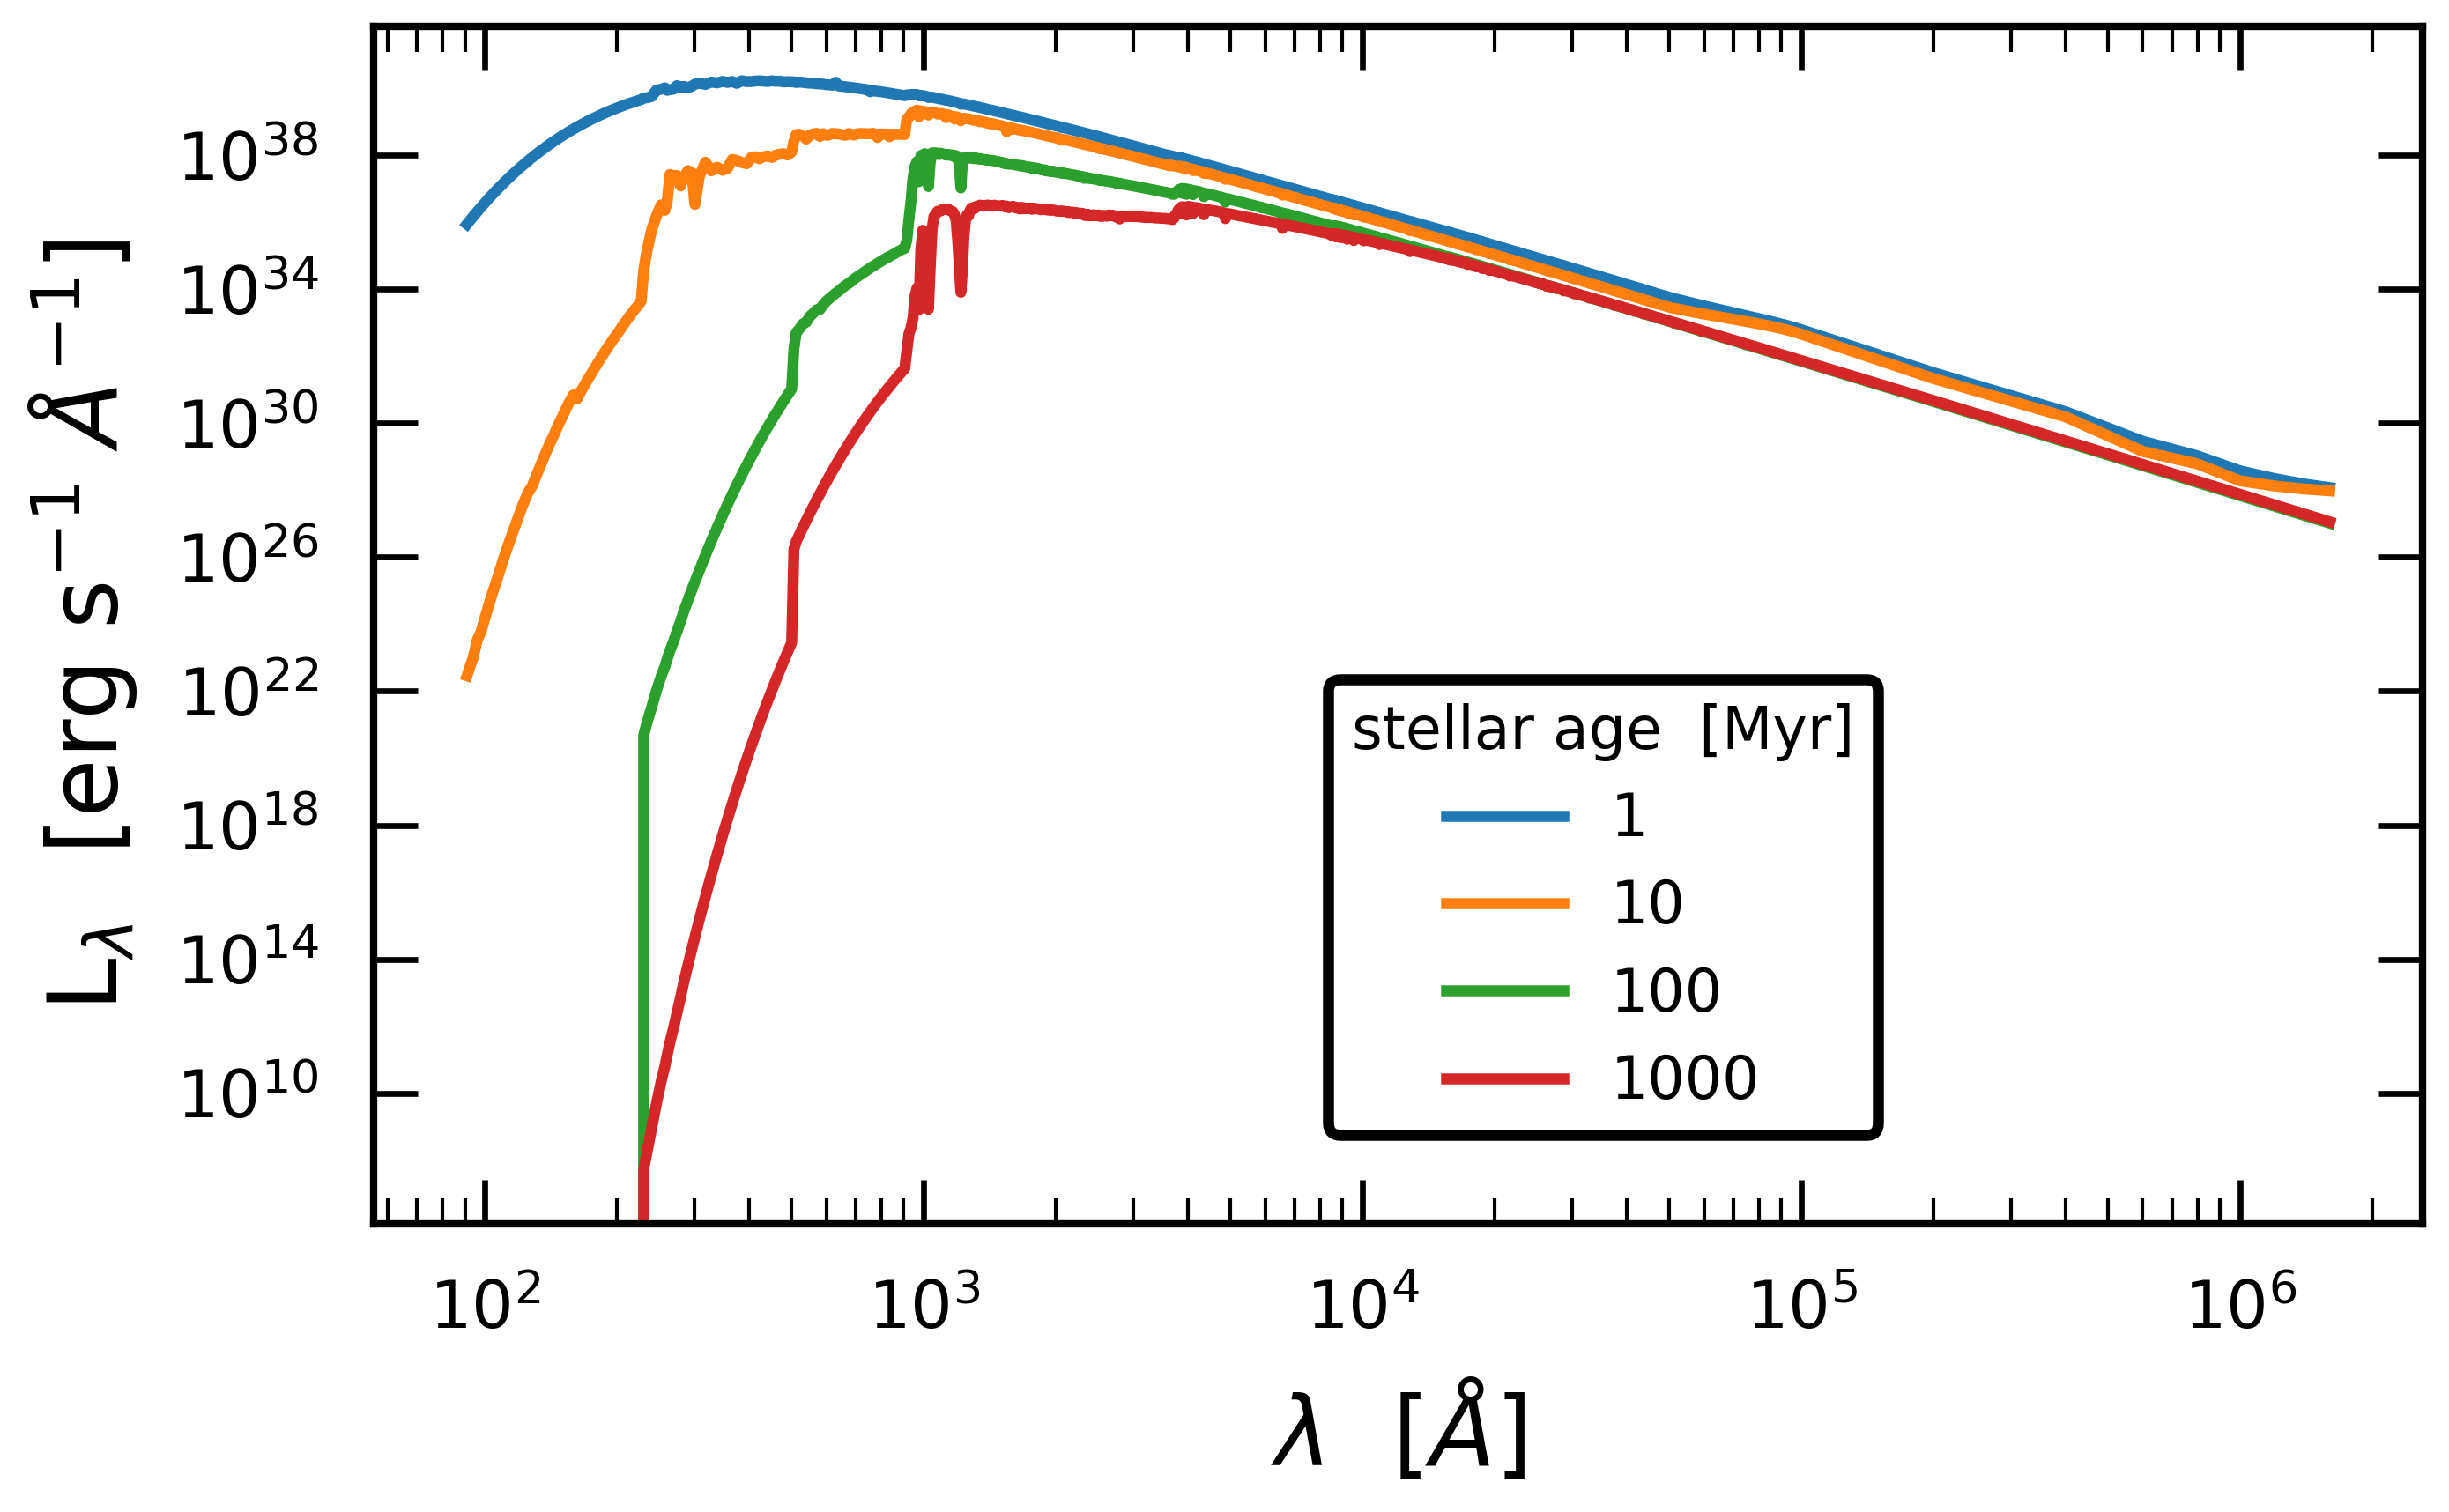

In [ ]:
fig, ax = plt.subplots()
for time_index in [50, 100, 150, 200]:
    ax.plot(
        spec_data.wl,
        spec_data.spec[time_index],
        lw=3,
        label=f"{int(spec_data.time[time_index] / 1e6)}")
leg = ax.legend(
    title="stellar age  [Myr]", fontsize="medium",
    loc="lower center", bbox_to_anchor=(0.6, 0.05))
leg.get_frame().set_linewidth(3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$  [$\AA$]")
ax.set_ylabel(r"L$_\lambda$  [erg s$^{-1}$ $\AA^{-1}$]")

# use the function to save the spectra as xarray.Dataset

In [2]:
convert_slug_spec_to_xr(
    "salp_zem3_1_300", Path(os.environ["SLUG_DATA_DIR"]))

<xarray.Dataset>
Dimensions:     (age: 251, wavelength: 1221)
Coordinates:
  * age         (age) float64 0.1 0.1047 0.1096 ... 9.12e+03 9.55e+03 1e+04
  * wavelength  (wavelength) float64 91.0 94.0 96.0 ... 1.2e+06 1.4e+06 1.6e+06
Data variables:
    luminosity  (age, wavelength) float64 4.554e+35 7.868e+35 ... 0.0 0.0
Attributes:
    description:  SLUG v2 spectra, generated from this param file: /cephfs/an...

In [2]:
convert_slug_spec_to_xr(
    "popIII_logtime_tracksvv00", Path(os.environ["SLUG_DATA_DIR"]))
convert_slug_spec_to_xr(
    "popIII_logtime_tracksvv40", Path(os.environ["SLUG_DATA_DIR"]))
convert_slug_spec_to_xr(
    "popII_logtime_tracksvv00", Path(os.environ["SLUG_DATA_DIR"]))
convert_slug_spec_to_xr(
    "popII_logtime_tracksvv40", Path(os.environ["SLUG_DATA_DIR"]))

<xarray.Dataset>
Dimensions:     (age: 251, wavelength: 1221)
Coordinates:
  * age         (age) float64 0.1 0.1047 0.1096 ... 9.12e+03 9.55e+03 1e+04
  * wavelength  (wavelength) float64 91.0 94.0 96.0 ... 1.2e+06 1.4e+06 1.6e+06
Data variables:
    luminosity  (age, wavelength) float64 2.475e+34 4.581e+34 ... 4.885e+26
Attributes:
    description:  SLUG v2 spectra, generated from this param file: /cephfs/an...